<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/01_gev_return_levels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import sys
import numpy as np
import pandas as pd
from datetime import datetime

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
os.chdir(PROJECT_DIR)

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print("Directorio actual:", os.getcwd())

Mounted at /content/drive
Directorio actual: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación


#IMPORTAR MODULOS


In [2]:
from scripts.station_analysis import procesar_estacion
from scripts.batch_return_levels import ejecutar_proceso_batch

# CONFIGURACIÓN GENERAL


In [3]:
# =============================
# CONFIGURACIÓN
# =============================
DIR_IN = os.path.join(PROJECT_DIR, "smn_downloads/Estaciones_Colima")
ARCHIVO_ESTACION = os.path.join(DIR_IN, "dat6001.csv")

COL_FECHA = "date"
COL_PP = "pp"

N_MIN_ANIOS = 10
NIVELES_RETORNO = np.array([2, 5, 10, 25, 50, 100], dtype=float)

N_BOOT = 500
ALPHA = 0.05
SEED = 42
USAR_BOOT_PARAMETRICO = True
PLOT_MAX_T = 100

DIR_OUT = os.path.join(DIR_IN, "_salidas_return_levels_robusto")
os.makedirs(DIR_OUT, exist_ok=True)

FECHA_TAG = datetime.now().strftime("%Y%m%d_%H%M")
RNG = np.random.default_rng(SEED)

#CURVA DE RETORNO PARA UNA ESTACIÓN

===== METADATA DE LA ESTACIÓN =====
station: dat6001
path: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6001.csv
png: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/dat6001_return_levels_ROBUST_20260320_2328.png
csv: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/dat6001_return_levels_ROBUST_20260320_2328.csv
n_years: 76
shape: -0.05878711723593706
loc: 90.51810141198757
scale: 51.915262273185064
trend_slope: 0.7874723171565283
bootA_naccepted: 475
bootB_naccepted: 490
note: 

📊 Curva de retorno generada:


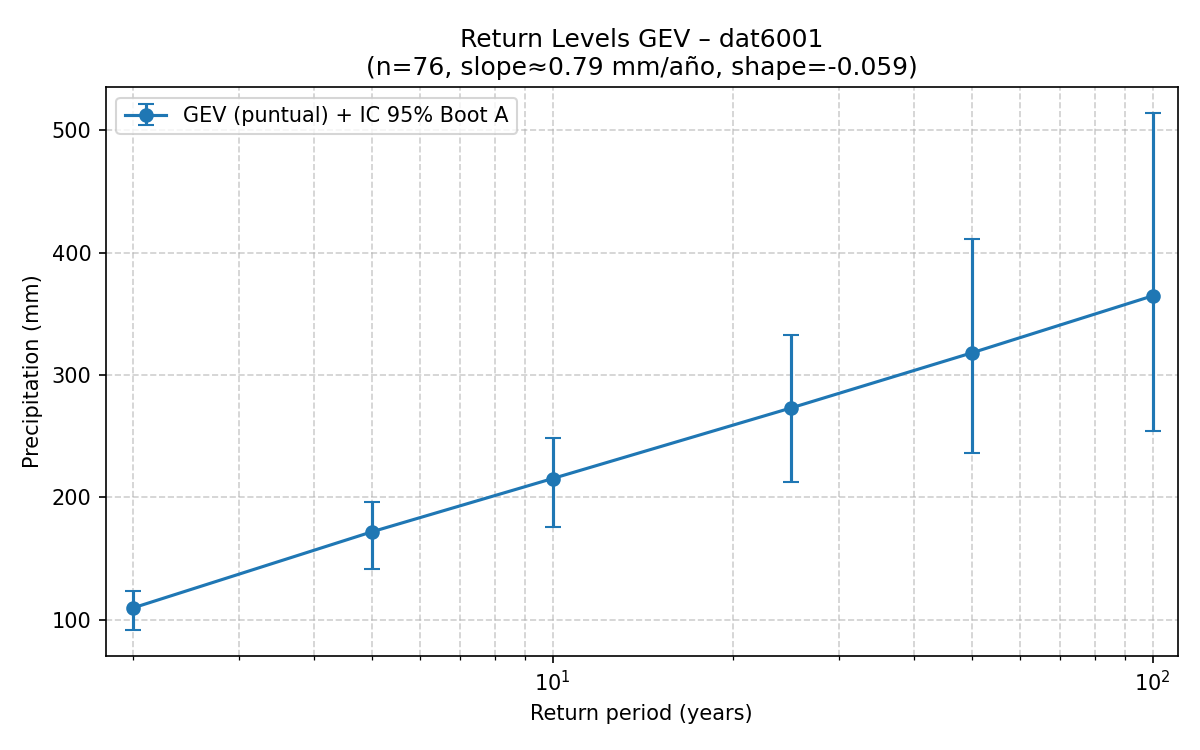


📁 Archivos generados:
PNG: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/dat6001_return_levels_ROBUST_20260320_2328.png
CSV: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/dat6001_return_levels_ROBUST_20260320_2328.csv

📋 Tabla de resultados:


,station,T_years,level_mm,CI_low95_bootA,CI_high95_bootA,bootA_naccepted,CI_low95_bootB,CI_high95_bootB,bootB_naccepted,gev_shape,gev_loc,gev_scale,n_years,trend_slope_mm_per_year,note
0,dat6001,2.0,109.752183,91.720737,123.387108,475,19.319811,1.256948e+02,490,-0.058787,90.518101,51.915262,76,0.787472,
1,dat6001,5.0,171.924220,141.152628,196.131312,475,85.663201,5.093743e+02,490,-0.058787,90.518101,51.915262,76,0.787472,
2,dat6001,10.0,215.426630,175.595072,248.400463,475,173.417650,1.783271e+04,490,-0.058787,90.518101,51.915262,76,0.787472,
3,dat6001,25.0,273.208796,212.359811,332.454508,475,215.923679,1.667503e+06,490,-0.058787,90.518101,51.915262,76,0.787472,
4,dat6001,50.0,318.204585,236.282461,410.950723,475,243.080637,3.948040e+07,490,-0.058787,90.518101,51.915262,76,0.787472,
5,dat6001,100.0,364.746583,254.536621,514.172040,475,266.958281,9.117758e+08,490,-0.058787,90.518101,51.915262,76,0.787472,


In [6]:
from IPython.display import Image, display

tabla_6001, meta_6001 = procesar_estacion(
    path_csv=ARCHIVO_ESTACION,
    col_fecha=COL_FECHA,
    col_pp=COL_PP,
    n_min_anios=N_MIN_ANIOS,
    niveles_retorno=NIVELES_RETORNO,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=RNG,
    usar_boot_parametrico=USAR_BOOT_PARAMETRICO,
    plot_max_t=PLOT_MAX_T,
    dir_out=DIR_OUT,
    fecha_tag=FECHA_TAG,
)

# =============================
# INFO GENERAL
# =============================
print("===== METADATA DE LA ESTACIÓN =====")
for k, v in meta_6001.items():
    print(f"{k}: {v}")

# =============================
# MOSTRAR GRÁFICA
# =============================
if "png" in meta_6001 and os.path.exists(meta_6001["png"]):
    print("\n📊 Curva de retorno generada:")
    display(Image(filename=meta_6001["png"]))
else:
    print("\n⚠️ No se encontró la imagen.")

# =============================
# MOSTRAR RUTAS DE SALIDA
# =============================
print("\n📁 Archivos generados:")
if "png" in meta_6001:
    print("PNG:", meta_6001["png"])
if "csv" in meta_6001:
    print("CSV:", meta_6001["csv"])

# =============================
# MOSTRAR TABLA
# =============================
print("\n📋 Tabla de resultados:")
display(tabla_6001)

# VER SOLO LA CURVA PUNTUAL E INTERVALOS

In [7]:
tabla_6001, meta_6001 = procesar_estacion(
    path_csv=ARCHIVO_ESTACION,
    col_fecha=COL_FECHA,
    col_pp=COL_PP,
    n_min_anios=N_MIN_ANIOS,
    niveles_retorno=NIVELES_RETORNO,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=RNG,
    usar_boot_parametrico=USAR_BOOT_PARAMETRICO,
    plot_max_t=PLOT_MAX_T,
    dir_out=DIR_OUT,
    fecha_tag=FECHA_TAG,
)

print("Meta de estación:")
print(meta_6001)

print("\nTabla de resultados:")
display(tabla_6001)

Meta de estación:
{'station': 'dat6001', 'path': '/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/dat6001.csv', 'png': '/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/dat6001_return_levels_ROBUST_20260320_2328.png', 'csv': '/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/dat6001_return_levels_ROBUST_20260320_2328.csv', 'n_years': 76, 'shape': np.float64(-0.05878711723593706), 'loc': np.float64(90.51810141198757), 'scale': np.float64(51.915262273185064), 'trend_slope': np.float64(0.7874723171565283), 'bootA_naccepted': 457, 'bootB_naccepted': 491, 'note': ''}

Tabla de resultados:


,station,T_years,level_mm,CI_low95_bootA,CI_high95_bootA,bootA_naccepted,CI_low95_bootB,CI_high95_bootB,bootB_naccepted,gev_shape,gev_loc,gev_scale,n_years,trend_slope_mm_per_year,note
0,dat6001,2.0,109.752183,92.268793,125.253883,457,21.595584,1.243434e+02,491,-0.058787,90.518101,51.915262,76,0.787472,
1,dat6001,5.0,171.924220,145.883078,194.593000,457,138.093366,5.402888e+02,491,-0.058787,90.518101,51.915262,76,0.787472,
2,dat6001,10.0,215.426630,181.411338,251.451170,457,180.368445,1.843340e+04,491,-0.058787,90.518101,51.915262,76,0.787472,
3,dat6001,25.0,273.208796,220.634358,338.124483,457,216.340860,1.568988e+06,491,-0.058787,90.518101,51.915262,76,0.787472,
4,dat6001,50.0,318.204585,248.367933,423.843681,457,241.273761,4.337697e+07,491,-0.058787,90.518101,51.915262,76,0.787472,
5,dat6001,100.0,364.746583,272.191274,523.465570,457,259.548614,1.201180e+09,491,-0.058787,90.518101,51.915262,76,0.787472,


# PROCESAR TODAS LAS ESTACIONES


Archivos encontrados: 37


/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:418: RuntimeWarning: invalid value encountered in scalar divide
  return m3 / np.power(m2, 1.5)



>>> CSV maestro:
/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/smn_downloads/Estaciones_Colima/_salidas_return_levels_robusto/MASTER_return_levels_GEV_ROBUST_20260320_2345.csv

Results:
station  T_years level_mm CI_low95_bootA CI_high95_bootA  bootA_naccepted CI_low95_bootB CI_high95_bootB  bootB_naccepted  gev_shape   gev_loc  gev_scale  n_years  trend_slope_mm_per_year note
dat6001      2.0   109.75          90.76          125.88              455          18.46          124.70              484  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001      5.0   171.92         146.21          195.77              455         135.04          524.20              484  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001     10.0   215.43         179.41          249.34              455         179.95        18816.06              484  -0.058787 90.518101  51.915262       76                 0.787472     
dat6001     25.0   273.21

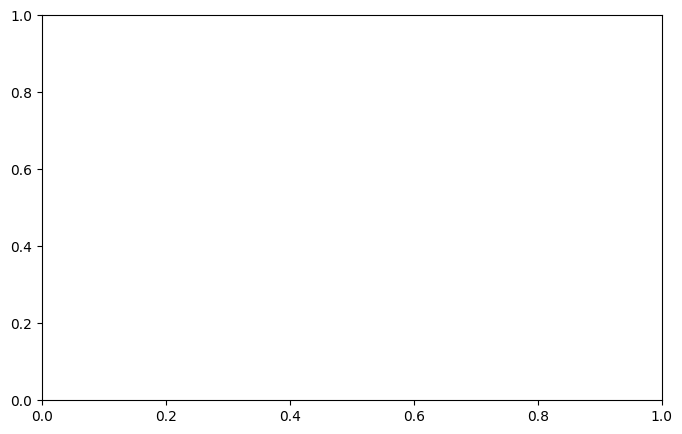

In [8]:
maestro, log_df, out_master, out_log = ejecutar_proceso_batch(
    dir_in=DIR_IN,
    patron="dat*.csv",
    col_fecha=COL_FECHA,
    col_pp=COL_PP,
    n_min_anios=N_MIN_ANIOS,
    niveles_retorno=NIVELES_RETORNO,
    n_boot=N_BOOT,
    alpha=ALPHA,
    seed=SEED,
    usar_boot_parametrico=USAR_BOOT_PARAMETRICO,
    plot_max_t=PLOT_MAX_T,
    nombre_salida_dir="_salidas_return_levels_robusto",
)

print("CSV maestro:", out_master)
print("Log:", out_log)

# VISTA RAPIDA DEL MAESTRO

In [9]:
if maestro is not None:
    display(maestro.head(20))
else:
    print("No se generó el maestro.")

,station,T_years,level_mm,CI_low95_bootA,CI_high95_bootA,bootA_naccepted,CI_low95_bootB,CI_high95_bootB,bootB_naccepted,gev_shape,gev_loc,gev_scale,n_years,trend_slope_mm_per_year,note
0,dat6001,2.0,109.752183,90.762453,125.878580,455,18.462319,1.247022e+02,484,-0.058787,90.518101,51.915262,76,0.787472,
1,dat6001,5.0,171.924220,146.211262,195.771103,455,135.044454,5.242031e+02,484,-0.058787,90.518101,51.915262,76,0.787472,
2,dat6001,10.0,215.426630,179.409118,249.336996,455,179.946870,1.881606e+04,484,-0.058787,90.518101,51.915262,76,0.787472,
3,dat6001,25.0,273.208796,217.660204,334.855027,455,220.625356,1.804489e+06,484,-0.058787,90.518101,51.915262,76,0.787472,
4,dat6001,50.0,318.204585,240.865111,418.076385,455,244.271915,5.332245e+07,484,-0.058787,90.518101,51.915262,76,0.787472,
5,dat6001,100.0,364.746583,261.703770,523.357827,455,264.366157,1.536905e+09,484,-0.058787,90.518101,51.915262,76,0.787472,
6,dat6002,2.0,79.472159,51.039182,87.515834,466,68.905890,8.947353e+01,495,0.051006,66.624610,35.382143,89,0.337949,
7,dat6002,5.0,117.716358,104.255336,129.907831,466,105.786192,1.313700e+02,495,0.051006,66.624610,35.382143,89,0.337949,
8,dat6002,10.0,141.847692,124.030302,159.084533,466,125.842461,1.598447e+02,495,0.051006,66.624610,35.382143,89,0.337949,
9,dat6002,25.0,171.046146,143.332177,199.643244,466,146.929749,1.983601e+02,495,0.051006,66.624610,35.382143,89,0.337949,


# FILTRAR UNA ESTACION DESDE EL MAESTRO

In [10]:
if maestro is not None:
    station_id = "dat6001"
    df_station = maestro[maestro["station"] == station_id].copy()
    print(f"Resultados para {station_id}:")
    display(df_station)

Resultados para dat6001:


,station,T_years,level_mm,CI_low95_bootA,CI_high95_bootA,bootA_naccepted,CI_low95_bootB,CI_high95_bootB,bootB_naccepted,gev_shape,gev_loc,gev_scale,n_years,trend_slope_mm_per_year,note
0,dat6001,2.0,109.752183,90.762453,125.878580,455,18.462319,1.247022e+02,484,-0.058787,90.518101,51.915262,76,0.787472,
1,dat6001,5.0,171.924220,146.211262,195.771103,455,135.044454,5.242031e+02,484,-0.058787,90.518101,51.915262,76,0.787472,
2,dat6001,10.0,215.426630,179.409118,249.336996,455,179.946870,1.881606e+04,484,-0.058787,90.518101,51.915262,76,0.787472,
3,dat6001,25.0,273.208796,217.660204,334.855027,455,220.625356,1.804489e+06,484,-0.058787,90.518101,51.915262,76,0.787472,
4,dat6001,50.0,318.204585,240.865111,418.076385,455,244.271915,5.332245e+07,484,-0.058787,90.518101,51.915262,76,0.787472,
5,dat6001,100.0,364.746583,261.703770,523.357827,455,264.366157,1.536905e+09,484,-0.058787,90.518101,51.915262,76,0.787472,


# RESUMEN DE ESTACIONES CON ADVERTENCIAS O PROBLEMAS

In [11]:
display(log_df.head(20))

if "note" in log_df.columns:
    print("Estaciones con advertencias:")
    display(log_df[log_df["note"].notna()])

,station,path,png,csv,n_years,shape,loc,scale,trend_slope,bootA_naccepted,bootB_naccepted,note,error
0,dat6001,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,76.0,-0.058787,90.518101,51.915262,0.787472,455.0,484.0,,NaN
1,dat6002,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,89.0,0.051006,66.624610,35.382143,0.337949,466.0,495.0,,NaN
2,dat6003,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,77.0,-0.133637,73.898532,45.915306,1.322564,484.0,492.0,,NaN
3,dat6004,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,64.0,-0.202437,72.256773,44.141520,1.438054,395.0,495.0,,NaN
4,dat6005,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,65.0,-0.050854,94.262375,58.365971,0.758684,453.0,474.0,,NaN
5,dat6006,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,84.0,0.047407,59.269237,47.345150,0.533379,462.0,459.0,,NaN
6,dat6007,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,69.0,-0.098117,69.276840,40.573028,0.450940,478.0,496.0,,NaN
7,dat6008,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,78.0,-0.124291,73.308603,38.568834,0.235093,447.0,500.0,,NaN
8,dat6009,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,64.0,0.076790,80.656588,40.539922,-0.049902,480.0,495.0,,NaN
9,dat6010,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,63.0,-0.072943,49.361870,32.305100,0.841983,488.0,494.0,,NaN


Estaciones con advertencias:


,station,path,png,csv,n_years,shape,loc,scale,trend_slope,bootA_naccepted,bootB_naccepted,note,error
0,dat6001,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,76.0,-0.058787,90.518101,51.915262,0.787472,455.0,484.0,,NaN
1,dat6002,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,89.0,0.051006,66.624610,35.382143,0.337949,466.0,495.0,,NaN
2,dat6003,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,77.0,-0.133637,73.898532,45.915306,1.322564,484.0,492.0,,NaN
3,dat6004,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,64.0,-0.202437,72.256773,44.141520,1.438054,395.0,495.0,,NaN
4,dat6005,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,65.0,-0.050854,94.262375,58.365971,0.758684,453.0,474.0,,NaN
5,dat6006,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,84.0,0.047407,59.269237,47.345150,0.533379,462.0,459.0,,NaN
6,dat6007,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,69.0,-0.098117,69.276840,40.573028,0.450940,478.0,496.0,,NaN
7,dat6008,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,78.0,-0.124291,73.308603,38.568834,0.235093,447.0,500.0,,NaN
8,dat6009,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,64.0,0.076790,80.656588,40.539922,-0.049902,480.0,495.0,,NaN
9,dat6010,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,/content/drive/MyDrive/Doctorado /Probabilidad...,63.0,-0.072943,49.361870,32.305100,0.841983,488.0,494.0,,NaN
